In [19]:
import numpy as np 
import matplotlib.pyplot as plt 

In [20]:
def softmax(x):
    x = np.array(x) 
    exp = np.exp(x-np.max(x)) 
    return exp/np.sum(exp) 

def cce(y_t, y_p):
    y_p = np.clip(y_p, 1e-12, 1-1e-12)
    return -np.sum(y_t*np.log(y_p))/y_t.shape[0] 

In [21]:
def fwd(x,w): 
    y_p = softmax(np.dot(x,w))
    print(np.sum(y_p))
    return y_p 

def bwd(x, y_t, y_p, lr): 
    grad = cce(y_t, y_p)
    dw = np.dot(x.T, grad)/x.shape[0]
    return dw * lr 

In [22]:
x = np.array([[1,2], [1.5,2.5], [2,3]])
w = np.array([[-0.5, 0.2, 0.3], [-0.6, 0.4, 0.7]])
y_t = np.array([[0,0,1], [0,1,0], [0,0,1]])

In [23]:
y_p = fwd(x,w) 
loss = cce(y_t, y_p) 
print("loss: ", loss) 
update = bwd(x, y_t, y_p, 0.1)
print(update)

0.9999999999999999
loss:  1.8152340104652078
[[0.0605078 0.0907617 0.1210156]
 [0.1210156 0.1512695 0.1815234]]


Text(0, 0.5, 'prob')

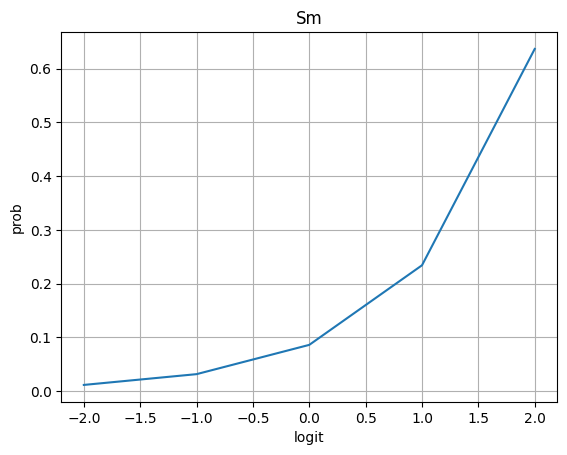

In [24]:
x = [-2,-1,0,1,2]
plt.plot(x, softmax(x))
plt.grid()
plt.title('Sm')
plt.xlabel('logit')
plt.ylabel('prob')